# An introduction to Agent AI based on LLM

In this exercise, I show how to create an AI agent using LLM. Agents are LLMs with reasoning and actions. They can take actions given a series of choices (tools). The thought process is the reasoning on how to arrive to an action or decision.

# The ReAct template

The template called "Reasoning and Acting" was the first iteration of an LLM based agents. This templates give agency to LLMs by providing an explanation of how to reason and act in a lop.

# Tools and agents

Agent AI based on LLMs must be provided with as series of tools.



# Links:

- ReAct framework

https://smith.langchain.com/hub/langchain-ai/react-agent-template

- langchain

https://github.com/emarco177/langchain-course


# Set up environment and load libraries

- load libraries
- install packages and tools
- authenticate to google drive and gcp account

General purpose libraries and packages

In [ ]:
pip install "geoai-py[agents]"

  Using cached openai-1.109.1-py3-none-any.whl.metadata (29 kB)
Using cached openai-1.109.1-py3-none-any.whl (948 kB)


In [ ]:
!pip install langchainhub
!pip install openai
!pip install langchain-openai
!pip install langchain
!pip install langchain-core
!pip install langchain-community
!pip install langchain-classic
!pip install duckduckgo-search
!pip install ddgs


  Using cached langchain_openai-1.1.10-py3-none-any.whl.metadata (3.1 kB)
  Using cached openai-2.22.0-py3-none-any.whl.metadata (29 kB)
Using cached langchain_openai-1.1.10-py3-none-any.whl (87 kB)
Using cached openai-2.22.0-py3-none-any.whl (1.1 MB)
  Attempting uninstall: openai
    Found existing installation: openai 1.109.1
    Uninstalling openai-1.109.1:
      Successfully uninstalled openai-1.109.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behav

In [ ]:
!pip install pystac_client
!pip install pystac
!pip install planetary-computer
!pip install geopy

In [ ]:
import langchain
langchain.__version__

'1.2.10'

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib import colors
import matplotlib.patches as mpatches
import seaborn as sns

import numpy as np
import subprocess
import pandas as pd
import os, glob
import zipfile

from pathlib import Path

sns.set_style('darkgrid')
#pd.set_option('display.max_colwidth', None)
!apt install unzip
import urllib
import re
import math
from datetime import datetime
from copy import deepcopy
from numpy.core.multiarray import datetime_as_string
import os
import numpy.ma as ma

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unzip is already the newest version (6.0-26ubuntu3.2).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


/tmp/ipython-input-975698043.py:25: DeprecationWarning: numpy.core.multiarray is deprecated and has been renamed to numpy._core.multiarray. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.multiarray.datetime_as_string.
  from numpy.core.multiarray import datetime_as_string


In [ ]:
import os
import glob
import tiktoken
import numpy as np
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings


In [ ]:
#Used in defining functions
from typing import List, Tuple, Dict, Any
from pandas.core.arrays import boolean

In [ ]:
import openai
import pystac

In [ ]:
!sudo apt install tree
!pip install tree
!pip install python-dotenv

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (114 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package tree.
(Reading database ... 117540 files and directories currently installe

In [ ]:
#GCP account authentification
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

Authenticated


In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
!pip install python-dotenv

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving .env to .env


Let's upload .env

In [ ]:
import dotenv
dotenv.load_dotenv('./.env')

True

# Functions
In the next part of the script, we declare all the functions used in the sripts.  It is good practice to place functions at the beginning of a script or in an external source file. Here are the 13 functions used:

In [ ]:
def create_dir_and_check_existence(path: str) -> str:
  '''
  Create a new directory

  :param path: path to the directory
  :return: path to the directory
  '''

  try:
    os.makedirs(path)
  except:
    print ("directory already exists")
  return path



# Parameters and Arguments

It is good practice to set all parameters and input arguments at the beginning of the script. This allows for better control and can make modifications of the scripts for other applications easier. Some arguments relate to path directories, input files and general parameters for use in the analyses (e.g. proportion of hold out).


In [ ]:

#ARG 1
in_dir = '/content/gdrive/MyDrive/Colab Notebooks/Large-Language-Models-applications/llm-agent-ai-intro/data/'
#ARG 2
out_dir = "/content/gdrive/MyDrive/Colab Notebooks/Large-Language-Models-applications/llm-agent-ai-intro"
#ARGS 3:
create_out_dir=True #create a new ouput dir if TRUE
#ARG 4
out_suffix = "20260211" #output suffix for the files and ouptut folder

random_seed=105 # set seed for reproducibility of results

llm_model_name = "gpt-3.5-turbo"
#llm_model_name = "gpt-4o-mini"


In [ ]:
#set up the working directory
#Create output directory

if create_out_dir==True:
    out_dir_new = "output_data_"+out_suffix
    out_dir = os.path.join(out_dir,"outputs",out_dir_new)
    create_dir_and_check_existence(out_dir)
    os.chdir(out_dir)        #set working directory
else:
    os.chdir(out_dir) #use working dir defined earlier


directory already exists


In [ ]:
print(out_dir)

/content/gdrive/MyDrive/Colab Notebooks/Large-Language-Models-applications/llm-agent-ai-intro/outputs/output_data_20260211


#1.Create a LLM with tools

To create an LLM agent, we need tools that can be used when performing a task. These tools allow the LLM to remain up to date. There three types of knowledge:

- LLM internal knowledge: acquired during training using training data with a "knowledge cut off date".

- external knowledge: acquired through tools or RAGs (external knowledge base).

Access to exernal knowledge can reduce the hallucination propensity and provide a means to keep the model up to date.

##1.1 Lanchchain tools

As a first example, we will ask who won the (American) Football championship from the NFL. The Super Bowl, the final of the championship, takes place every year early February in the USA. If we ask a LLM, the winner of the last Super Bowl, we will get a different answer if we use the internal knowledge or if we use tools through a LLM or LLM agent.

First let's define a web search tool using Langchain. We use DuckDuckGo as a search engine. It does not require writing any specific code and can be imported directly from the "langchain_community" package.

In [ ]:
from langchain_community.tools import DuckDuckGoSearchRun

# Initialize the search tool
search = DuckDuckGoSearchRun()

# Run a query
result = search.run("Who won the last Super Bowl?")
print(result)

The New England Patriots won Super Bowls XLIX, LI, and LIII for three titles in five seasons. They also appeared in and lost Super Bowl LII to the Philadelphia Eagles following the 2017 season, giving them four Super Bowl appearances in five years. View a comprehensive list of every single NFL Super Bowl champion from 1967 to present on ESPN. Includes the finals opponent, site of the game and the final result. Your Pro Football Reference recap is here! See most viewed players, teams, and more . Super Bowl History. Super Bowl History. + indicates Hall of Fame. Table. The Lombardi Trophy is heading back to Seattle. The Sporting News tracked updates, highlights and more from Super Bowl 60, where the Seahawks took down the Patriots. Who won the last Super Bowl in 2025? The Philadelphia Eagles won last year’s Super Bowl , which was Super Bowl LIX at the end of the 2024 NFL season. They defeated the Kansas City Chiefs by a decisive score of 40-22 on February 9, 2025.


Let's use the search tool from DuckDuckGo and bind it to our LLM to create a LLM with tools.

In [ ]:
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent

tools = [search]
# Initialize the model and bind the tools to it
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)
#llm = ChatOpenAI(model="gpt-3.5", temperature=0)

llm_with_tools = llm.bind_tools(tools)
type(llm_with_tools)

langchain_core.runnables.base.RunnableBinding

Let's use the LLM model without tools. We can clearly see below that this information is not available. The returned response reference the 2021 Super Bowl which implies some knowledge cutoff date around that year or before February 2022.

In [ ]:
result1 = llm.invoke("Who won the last super bowl")
print(result1)
print(result1.content)

content='The Tampa Bay Buccaneers won the last Super Bowl, which was Super Bowl LV in 2021.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 13, 'total_tokens': 33, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DCauL6tRFKxyzio7LX50h7UaCNMxH', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019c8d1f-8d2f-7092-b517-e3bc60f1e886-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 13, 'output_tokens': 20, 'total_tokens': 33, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
The Tampa Bay Buccaneers won the last Super Bowl, which was Super Bowl LV in 2021

Let's use the model with tools. Note that the response is empty and the LLM did not use the tool available to search on the web for the query answer.

In [ ]:
result2 = llm_with_tools.invoke("Who won the last super bowl")
print(result2)
print(result2.content)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 82, 'total_tokens': 102, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DCavE3blaFE7xAgrht6LpdFKutEk0', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019c8d20-64a8-7130-baaa-c8ab07a9b359-0' tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'last Super Bowl winner'}, 'id': 'call_vwp0RHXP1TrGJ4zu16RoAB1Q', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 82, 'output_tokens': 20, 'total_tokens': 102, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}



##1.2 Custom agent tools

We can also create custom agent tools for the LLM agent. Using langchain, this involves writing a function with the decorator "@tool" which modifies the function into a langchain tool.

In this example, we create two tools:

- a weather tool: to provide weather at specific location. This relies on the weatherapi.com website. You will need to create a API key to access it but it is free (for a limited number of calls).

- web search tool: we can use TAVILY (which requires an API key) or DuckDuckGo.


https://medium.com/pythoneers/building-ai-agent-systems-with-langgraph-9d85537a6326


In [ ]:
import requests

WEATHER_API_KEY = os.environ['WEATHER_API_DOT_COM']

@tool
def get_weather(query: str) -> list:
    """Search weatherapi to get the current weather"""
    endpoint = f"http://api.weatherapi.com/v1/current.json?key={WEATHER_API_KEY}&q={query}"
    response = requests.get(endpoint)
    data = response.json()

    if data.get("location"):
        return data
    else:
        return "Weather Data Not Found"

@tool
def search_web(query: str) -> list:
    """Search the web for a query"""
    tavily_search = TavilySearchResults(api_key=TAVILY_API_KEY, max_results=2, search_depth='advanced', max_tokens=1000)
    results = tavily_search.invoke(query)
    return results

Let's first bind the tools to the LLM.

In [ ]:
del llm
#llm = ChatOpenAI(model="gpt-3.5")
llm = ChatOpenAI(model="gpt-3.5-turbo")

# If you have OpenAI key
# llm = ChatOpenAI(model="gpt-4o-mini", api_key="sk-U7tijaa4jwHvhVWGr....", temperature=0)

#tools = [search_web, get_weather]
tools = [search, get_weather]

llm_with_tools = llm.bind_tools(tools)

We provide a query/task to the LLM. This requires accessing the weather and web search tools.

In [ ]:
query = "What is the current weather in Brussels today. Please provide the date of the current weather as well"
response = llm.invoke(query)
print(response.content)

As an AI language model, I do not have real-time data. To find the current weather in Brussels today, you can use a weather website or app like Weather.com or AccuWeather and enter today's date.


In [ ]:
prompt = """
    Given only the tools at your disposal, mention tool calls for the following tasks:
    Do not change the query given for any search tasks
        1. What is the current weather in Brussels today?
        2.  What is the date today?
        3. Can you tell me about Brussels?
      """

results = llm_with_tools.invoke(prompt)

print(results.tool_calls)
print("\n")
print(results.content)

[{'name': 'get_weather', 'args': {'query': 'Brussels'}, 'id': 'call_eWiSD4i8ad42x6NtL4Zn0030', 'type': 'tool_call'}, {'name': 'duckduckgo_search', 'args': {'query': 'date today'}, 'id': 'call_o86ic86aYQrdUZ6RqeIeWtmA', 'type': 'tool_call'}, {'name': 'duckduckgo_search', 'args': {'query': 'Brussels'}, 'id': 'call_8eh7hQffWdZ9mvcknkGJcPxW', 'type': 'tool_call'}]





We can see that the LLM attempted to use the tools but it did not provide any response. Let's now create and AI agent to leverage the available tools.

#2.ReAct Agent: the react template

The original first agent was created using a chat template describing the task as a sequence of thought and action. This approach was published in the paper "ReAct: Synergizing Reasoning and Acting in Language Models" (Oct 2022). The observation is the output of an action while the action input is the input to an action. The process of decision making or is described in the thought part of the LLM template.

Note thate the react template and hub module has been moved to the langchain classic package after moving to langchain 1.+

links:

React paper:

https://arxiv.org/abs/2210.03629

https://medium.com/@terrycho/how-langchain-agent-works-internally-trace-by-using-langsmith-df23766e7fb4

https://github.com/emarco177/langchain-course

In [ ]:
import langchain_classic
langchain_classic.__version__

'1.0.1'

In [ ]:
from langchain_classic import hub

# Pull the latest version of a prompt
#prompt = hub.pull("hwchase17/openai-functions-agent")
prompt_react = hub.pull("hwchase17/react")
prompt_react

PromptTemplate(input_variables=['agent_scratchpad', 'input', 'tool_names', 'tools'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'hwchase17', 'lc_hub_repo': 'react', 'lc_hub_commit_hash': 'd15fe3c426f1c4b3f37c9198853e4a86e20c425ca7f4752ec0c9b0e97ca7ea4d'}, template='Answer the following questions as best you can. You have access to the following tools:\n\n{tools}\n\nUse the following format:\n\nQuestion: the input question you must answer\nThought: you should always think about what to do\nAction: the action to take, should be one of [{tool_names}]\nAction Input: the input to the action\nObservation: the result of the action\n... (this Thought/Action/Action Input/Observation can repeat N times)\nThought: I now know the final answer\nFinal Answer: the final answer to the original input question\n\nBegin!\n\nQuestion: {input}\nThought:{agent_scratchpad}')

In [ ]:
from IPython.display import display, Markdown
Markdown(prompt_react.template)

Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: {input}
Thought:{agent_scratchpad}

We import from the langchain_classic package because the latest langchain package does not have a specific react agent implementation.

In [ ]:
from langchain_classic.agents.react.agent import create_react_agent
from langchain_classic.agents import AgentExecutor

In [ ]:
langchain_classic.agents.react.agent.create_react_agent

<function langchain_classic.agents.react.agent.create_react_agent(llm: 'BaseLanguageModel', tools: 'Sequence[BaseTool]', prompt: 'BasePromptTemplate', output_parser: 'AgentOutputParser | None' = None, tools_renderer: 'ToolsRenderer' = <function render_text_description at 0x7996da0062a0>, *, stop_sequence: 'bool | list[str]' = True) -> 'Runnable'>

The react agent will use the ReAct prompt format when acting to resolve the task.

In [ ]:
langchain_classic.agents.AgentExecutor #simple loop

langchain_classic.agents.agent.AgentExecutor

By setting up an agent with chain executor, this will run the react chain in a while loop until we get the answer we want.

In [ ]:
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
#from langchain_classic.agents.react.agent import create_react_agent
#from langchain_classic.agents import AgentExecutor

tools = [search]
# Initialize the model and bind the tools to it
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)
#llm = ChatOpenAI(model="gpt-3.5", temperature=0)

#create a sequence chain that we will call agent
agent = create_react_agent(llm,
                     tools,
                     prompt=prompt_react)
print(type(agent))
message_user =  """ Please respond to the following:
        1. What is the current weather in Brussels today?
        2. What is the date today?
        3. Can you tell me about Brussels?
      """
chain_agent = AgentExecutor(agent=agent, tools=tools, verbose=True)
chain_agent.invoke({"input": message_user})
#agent.invoke({"input": "What is the current weather in Trivandrum today"})

<class 'langchain_core.runnables.base.RunnableSequence'>


> Entering new AgentExecutor chain...
I should use the duckduckgo_search tool to find the answers to these questions.
Action: duckduckgo_search
Action Input: current weather in BrusselsUse Current Location. Recent. Brussels . Weather Near Brussels : Grimbergen, Flemish Brabant. Sint-Pieters-Woluwe, Brussels . Outlook forecast map. Brussels . 10:00 Monday. Weather key. Weather Forecast for Brussels | euronews, previsions for Brussels , Belgium (temperature, wind, rainfall…). Current local time in Belgium – Brussels . Get Brussels 's weather and area codes, time zone and DST. 03/02/2026. Cool roofs can greatly reduce the impact of heat waves in cities. Meer nieuws. Weather .I need to search for the date today.
Action: duckduckgo_search
Action Input: date today3 weeks ago - Today (archaically to-day) usually refers to: The current day and calendar date · Today is between Thursday, 19 February 2026 and Saturday, 21 February 2026 , 

{'input': ' Please respond to the following:\n        1. What is the current weather in Brussels today?\n        2. What is the date today?\n        3. Can you tell me about Brussels?\n      ',
 'output': '1. The current weather in Brussels today is cool.\n2. The date today is Monday, February 23, 2026.\n3. Brussels is the capital city of Belgium, with vibrant attractions and a rich history.'}

#3.Creating agent with langgraph

The ReAct prompt is not usually used in most agent creation. The langchain implementation has moved to the langgraph implementation which tracks the states of the multiple llm calls to the to the tools. Below, I provide an example of the new AI agent object in langgraph>

Links:

- https://medium.com/pythoneers/building-ai-agent-systems-with-langgraph-9d85537a6326


Let's first create an agent without a tool:

<class 'langgraph.graph.state.CompiledStateGraph'>


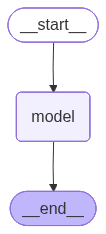

In [ ]:
tools = []
agent=langchain.agents.create_agent(model='gpt-3.5-turbo',tools=tools)
print(type(agent))
agent

Now let's add two tools. We used the same tools defined earlier:
- weather tool
- web search tool

<class 'langgraph.graph.state.CompiledStateGraph'>


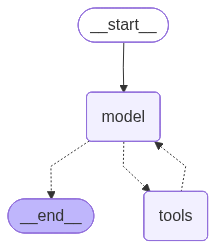

In [ ]:
#llm = ChatOpenAI(model="gpt-4o", temperature=0)
tools = [search, get_weather]
agent=langchain.agents.create_agent(model='gpt-3.5-turbo',tools=tools,)
print(type(agent))
agent

In [ ]:
#llm = ChatOpenAI(model="gpt-4o", temperature=0)
tools = [search, get_weather]
agent=langchain.agents.create_agent(model='gpt-3.5-turbo',tools=tools,)
print(type(agent))
message_user =  """ Please respond to the following:
        1. What is the current weather in Brussels today?
        2. What is the date today?
        3. Can you tell me about Brussels?
      """
agent.invoke({"messages": [("user", "What is the current weather in Nice today")]})
agent.invoke({"messages": [("user", message_user)]})


<class 'langgraph.graph.state.CompiledStateGraph'>


{'messages': [HumanMessage(content=' Please respond to the following:\n        1. What is the current weather in Brussels today?\n        2. What is the date today?\n        3. Can you tell me about Brussels?\n      ', additional_kwargs={}, response_metadata={}, id='e306a784-d1b1-4145-878b-0da5a11f9933'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 141, 'total_tokens': 207, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DCbA6ertfmqIzt3yJ3K39QBoXOPWx', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c8d2e-7494-7a11-b687-a1bb61b57fbf-0', tool_calls=[{'name': 'get_weather', 'args': {'query':

#4.Intro to geo-AI agent: searching for Sentinel 2  imagery with STAC


Now that we have learned about agents, we can apply some of knowledge by creating a 'geo-ai agent'. As an example, we will create a an AI agent that can find satellite image for specific locations and days. We will use the STACT API interface to interact with the agent.

Let's first define a STAC tool to associate to the LLM. Note that this code was in part generated by Gemini and ChatGPT and modified substantially.

In [ ]:
import os
from datetime import datetime
from typing import List, Optional
from langchain.tools import tool
from pystac_client import Client
import planetary_computer as pc

# Initialize STAC Client (e.g., Microsoft Planetary Computer)
STAC_API_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"
catalog = Client.open(STAC_API_URL, modifier=pc.sign_inplace)

@tool
def search_stac_items(
    bbox: List[float],
    datetime_range: str,
    collections: List[str] = ["sentinel-2-l2a"],
    limit: int = 10
) -> str:
    """
    Search for satellite imagery in a STAC catalog.
    Args:
        bbox: A list of 4 floats [min_lon, min_lat, max_lon, max_lat].
        datetime_range: A RFC3339 string (e.g., '2023-01-01/2023-12-31').
        collections: List of STAC collection IDs. Defaults to Sentinel-2.
    """
    search = catalog.search(
        collections=collections,
        bbox=bbox,
        datetime=datetime_range,
        max_items=limit
    )

    items = list(search.items())
    if not items:
        return "No items found for this query."

    # Format simplified results for the LLM to read
    results = []
    for item in items:
        results.append({
            "id": item.id,
            "date": item.datetime.strftime("%Y-%m-%d"),
            "cloud_cover": item.properties.get("eo:cloud_cover", "N/A"),
            "thumbnail": item.assets.get("thumbnail", {}).get("href", "No thumbnail"),
            "assets": item.assets
        })
    return str(results)


Let's define a new agent with the new STAC tool.

<class 'langgraph.graph.state.CompiledStateGraph'>


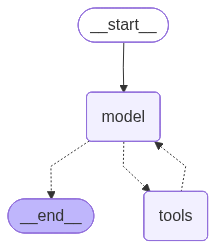

In [ ]:
llm = ChatOpenAI(model="gpt-4o", temperature=0)
tools = [search_stac_items]
agent=langchain.agents.create_agent(model=llm,tools=tools)
print(type(agent))
agent

Now, let's query the agent. We would like to return Sentinel 2 imagery from San Fransisco with low cloud cover on a specific date:

In [ ]:
agent.invoke({"input": "Find Sentinel-2 images of Washington DC from January 2026 with low cloud cover."})

BadRequestError: Error code: 400 - {'error': {'message': "Invalid 'messages': empty array. Expected an array with minimum length 1, but got an empty array instead.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'empty_array'}}

Key Implementation Details
Bounding Box Management: For a production agent, you should add a Geocoding Tool (e.g., using OpenStreetMap) so the agent can convert "San Francisco" into the required bbox coordinates automatically.
Result Formatting: LLMs have token limits; do not return the raw, massive STAC JSON. Extract only the IDs, dates, and preview links as shown above.
Authentication: The planetary_computer.sign_inplace modifier is specific to Microsoft’s API to allow direct access to Planetary Computer assets.

##4.2. Adding geocoding tool

This code was in part generated by Gemini and ChatGPT and modified by me.

In [ ]:
!pip install geopy

from geopy.geocoders import Nominatim
from langchain.tools import tool

# Initialize geocoder
geolocator = Nominatim(user_agent="stac_llm_agent_tutorial")


def get_bbox_from_address_test(address: str) -> list[float]:
    """
    Converts a city or place name into a bounding box [min_lon, min_lat, max_lon, max_lat].
    Use this first whenever a user mentions a place name instead of coordinates.
    """
    location = geolocator.geocode(address, geometry='geojson')
    if not location:
        return "Location not found."

    # Extract the bounding box from the raw response
    # Nominatim returns [min_lat, max_lat, min_lon, max_lon]
    raw_bbox = location.raw.get('boundingbox')
    if raw_bbox:
        # Convert to STAC standard: [min_lon, min_lat, max_lon, max_lat]
        return [float(raw_bbox[2]), float(raw_bbox[0]), float(raw_bbox[3]), float(raw_bbox[1])]

    # Fallback to a small buffer around a single point if bbox isn't available
    lon, lat = location.longitude, location.latitude
    return [lon - 0.01, lat - 0.01, lon + 0.01, lat + 0.01]
# Include both the STAC search tool and the new geocoder


@tool
def get_bbox_from_address(address: str) -> list[float]:
    """
    Converts a city or place name into a bounding box [min_lon, min_lat, max_lon, max_lat].
    Use this first whenever a user mentions a place name instead of coordinates.
    """
    location = geolocator.geocode(address, geometry='geojson')
    if not location:
        return "Location not found."

    # Extract the bounding box from the raw response
    # Nominatim returns [min_lat, max_lat, min_lon, max_lon]
    raw_bbox = location.raw.get('boundingbox')
    if raw_bbox:
        # Convert to STAC standard: [min_lon, min_lat, max_lon, max_lat]
        return [float(raw_bbox[2]), float(raw_bbox[0]), float(raw_bbox[3]), float(raw_bbox[1])]

    # Fallback to a small buffer around a single point if bbox isn't available
    lon, lat = location.longitude, location.latitude
    return [lon - 0.01, lat - 0.01, lon + 0.01, lat + 0.01]
# Include both the STAC search tool and the new geocoder




Let's first test the function:

In [ ]:
get_bbox_from_address_test("Washington DC")

[-77.1197949, 38.7916303, -76.909366, 38.995968]

Now we have two tools that can be used when responding:

- bounding box function tool based on query location (e.g. San Fransisco).
- stac tool function to return the available Sentinel 2 data using the STAC approach.

In [ ]:
llm = ChatOpenAI(model="gpt-4o", temperature=0)
tools = [get_bbox_from_address, search_stac_items]
agent=langchain.agents.create_agent(model=llm,tools=tools)
print(type(agent))
agent
# The rest remains the same
#agent = create_openai_tools_agent(llm, tools, prompt)
#agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

# Test with a natural language city name
#query = "Search for recent Sentinel-2 images over Tokyo with less than 10% clouds."
#query = "Find 3 Sentinel-2 images of San Francisco from July 2023 with low cloud cover."

#agent.invoke({"messages": [("user", "Find 3 Sentinel-2 images of San Francisco from January 2025 with low cloud cover.")]})
result_stac_agent = agent.invoke({"messages": [("user", "Find 3 Sentinel-2 images of Washington DC from January 2026 with less than 15% cloud cover.")]})
result_stac_agent


<class 'langgraph.graph.state.CompiledStateGraph'>


{'messages': [HumanMessage(content='Find 3 Sentinel-2 images of Washington DC from January 2026 with less than 15% cloud cover.', additional_kwargs={}, response_metadata={}, id='7410680d-bc77-4e0d-b4f4-e0a377cca827'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 226, 'total_tokens': 243, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_7e79d70c47', 'id': 'chatcmpl-DCbN1GhjAhjwLE0lorhXNtSBhjxk7', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c8d3a-aebc-7c31-9c26-2c3aaf0f4585-0', tool_calls=[{'name': 'get_bbox_from_address', 'args': {'address': 'Washington DC'}, 'id': 'call_kdkEqruMvuScMQP26m71L4L3', 'type': '

The agent LLM response is structured as a list of messages of length 6:

- HumanMessage: this is the input query
- AIMessage 1: this is the first response  (tool_call #1), (ACTION 1)
- ToolMessage: this is the result from calling the tool call 1 (bbox result), OBSERVATION 1
- AIMessage:  (tool_call #2), (ACTION 2)
- ToolMessage (STAC results) (OBSERVATION 2
- AIMessage: final response

Let's first show the HumanMessage, which is the original prompt describing the task that LLM must complete:

In [ ]:
print(type(result_stac_agent))
print(len(result_stac_agent)) #one dict with length one with key 'messages
print(len(result_stac_agent.get('messages')))
print((result_stac_agent.get('messages')[0]))

<class 'dict'>
1
6
content='Find 3 Sentinel-2 images of Washington DC from January 2026 with less than 15% cloud cover.' additional_kwargs={} response_metadata={} id='7410680d-bc77-4e0d-b4f4-e0a377cca827'


Let's show the last AIMessage, which is the final response from the AI agent (also called assisant):

In [ ]:
result_stac_agent.get('messages')[5]

AIMessage(content='I found three Sentinel-2 images of Washington DC from January 2026. However, only two of them have less than 15% cloud cover:\n\n1. **Image ID:** S2C_MSIL2A_20260129T155511_R054_T18SUH_20260129T193112\n   - **Date:** 2026-01-29\n   - **Cloud Cover:** 6.20%\n   - [Rendered Preview](https://planetarycomputer.microsoft.com/api/data/v1/item/preview.png?collection=sentinel-2-l2a&item=S2C_MSIL2A_20260129T155511_R054_T18SUH_20260129T193112&assets=visual&asset_bidx=visual%7C1%2C2%2C3&nodata=0&format=png)\n\n2. **Image ID:** S2C_MSIL2A_20260129T155511_R054_T18SUJ_20260129T193112\n   - **Date:** 2026-01-29\n   - **Cloud Cover:** 19.20% (Note: This exceeds the 15% cloud cover threshold)\n   - [Rendered Preview](https://planetarycomputer.microsoft.com/api/data/v1/item/preview.png?collection=sentinel-2-l2a&item=S2C_MSIL2A_20260129T155511_R054_T18SUJ_20260129T193112&assets=visual&asset_bidx=visual%7C1%2C2%2C3&nodata=0&format=png)\n\n3. **Image ID:** S2B_MSIL2A_20260127T160429_R097

##4.3. Adding output formatting

We can ask chat gpt to get a nicer format. I extracted this function below from chatGPT.

In [ ]:
def pretty_ai_message(msg):
    print("🤖 AI Response\n" + "-"*40)
    print(msg.content)
    print("\n📊 Token Usage")
    print(f"Input: {msg.usage_metadata['input_tokens']}")
    print(f"Output: {msg.usage_metadata['output_tokens']}")
    print(f"Total: {msg.usage_metadata['total_tokens']}")

In [ ]:
pretty_ai_message(result_stac_agent.get('messages')[5])

🤖 AI Response
----------------------------------------
I found three Sentinel-2 images of Washington DC from January 2026. However, only two of them have less than 15% cloud cover:

1. **Image ID:** S2C_MSIL2A_20260129T155511_R054_T18SUH_20260129T193112
   - **Date:** 2026-01-29
   - **Cloud Cover:** 6.20%
   - [Rendered Preview](https://planetarycomputer.microsoft.com/api/data/v1/item/preview.png?collection=sentinel-2-l2a&item=S2C_MSIL2A_20260129T155511_R054_T18SUH_20260129T193112&assets=visual&asset_bidx=visual%7C1%2C2%2C3&nodata=0&format=png)

2. **Image ID:** S2C_MSIL2A_20260129T155511_R054_T18SUJ_20260129T193112
   - **Date:** 2026-01-29
   - **Cloud Cover:** 19.20% (Note: This exceeds the 15% cloud cover threshold)
   - [Rendered Preview](https://planetarycomputer.microsoft.com/api/data/v1/item/preview.png?collection=sentinel-2-l2a&item=S2C_MSIL2A_20260129T155511_R054_T18SUJ_20260129T193112&assets=visual&asset_bidx=visual%7C1%2C2%2C3&nodata=0&format=png)

3. **Image ID:** S2B_MSI

Let's modify to return a table with all the relevant bands in a pandas format.

In [ ]:
result_stac_agent2 = agent.invoke({"messages": [("user", "Find 3 Sentinel-2 images of Washington DC from January 2026 with less than 15% cloud cover. Please return also a json with assets bands including Red, Blue, Green and NIR")]})
result_stac_agent2

{'messages': [HumanMessage(content='Find 3 Sentinel-2 images of Washington DC from January 2026 with less than 15% cloud cover. Please return also a json with assets bands including Red, Blue, Green and NIR', additional_kwargs={}, response_metadata={}, id='3456419d-adf1-4743-b538-75a0c3228426'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 243, 'total_tokens': 260, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a147b6a959', 'id': 'chatcmpl-DCbUfYMtMyJTsnRPJakxttign6M90', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c8d41-ec3d-74c3-9533-80aadbd79327-0', tool_calls=[{'name': 'get_bbox_from_address', 'args':

In [ ]:
result_stac_agent2.get('messages')[5]

AIMessage(content='I found three Sentinel-2 images of Washington DC from January 2026. However, only two of them have less than 15% cloud cover. Here are the details:\n\n1. **Image ID:** S2C_MSIL2A_20260129T155511_R054_T18SUH_20260129T193112\n   - **Date:** 2026-01-29\n   - **Cloud Cover:** 6.20%\n   - **Assets:**\n     - **Red (B04):** [Link](https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/18/S/UH/2026/01/29/S2C_MSIL2A_20260129T155511_N0511_R054_T18SUH_20260129T193112.SAFE/GRANULE/L2A_T18SUH_A007317_20260129T155511/IMG_DATA/R10m/T18SUH_20260129T155511_B04_10m.tif)\n     - **Green (B03):** [Link](https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/18/S/UH/2026/01/29/S2C_MSIL2A_20260129T155511_N0511_R054_T18SUH_20260129T193112.SAFE/GRANULE/L2A_T18SUH_A007317_20260129T155511/IMG_DATA/R10m/T18SUH_20260129T155511_B03_10m.tif)\n     - **Blue (B02):** [Link](https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/18/S/UH/2026/01/29/S2C_MSIL2A_20260129T155511_N0511_R054_T18S

We can see that the AGENT did not return in desired format. We would need additional function to prepare the output.

#5.Geo-AI agent with python package

The geoai package is an open source package created by Qiusheng Wu at the U. of Tenesse. It leverages LLM agents to provide a natural language interface to perform various processing and analytical tasks on geospatial and Remote Sensing datasets.

To create agents, it uses the "Strands" framework and package published by Amazon (see link below).

Links:

- https://garystafford.medium.com/introducing-aws-strands-agents-a-new-paradigm-in-ai-agent-development-1d7c99588315
- https://github.com/opengeos/geoai/blob/main/geoai/agents/geo_agents.py
- https://opengeoai.org/examples/STAC_agents/
- https://opengeoai.org/examples/AI_agents/
- https://opengeoai.org/installation/#upgrading


In [ ]:
import json
from geoai import Map
from geoai.agents import (
    STACAgent,
    STACTools,
    create_ollama_model,
    create_openai_model,
    create_anthropic_model,
    create_bedrock_model,
)

The geo-ai packages allows for different LLM to be used as agents. We will use the open AI model since we have a API Key. Another option is to use LLama3.1 with Ollama since it is free but this requires having a Ollam server running.

In [ ]:
#model = create_ollama_model(model="llama3.1")
import os
model = create_openai_model(model="gpt-3.5-turbo",api_key=os.getenv("OPENAI_API_KEY") )

Let's use the LLM model to create an agent with STAC tool following the example provided in the geo-AI package (see the link below).

https://opengeoai.org/examples/STAC_agents/


In [ ]:
tools = STACTools()
tools.list_collections()

Retrieved 134 collections from Planetary Computer


'{\n  "count": 134,\n  "filter_keyword": null,\n  "collections": [\n    {\n      "id": "3dep-lidar-classification",\n      "title": "USGS 3DEP Lidar Classification",\n      "description": "This collection is derived from the [USGS 3DEP COPC collection](https://planetarycomputer.microsoft....",\n      "license": null,\n      "temporal_extent": null,\n      "spatial_extent": null,\n      "providers": null,\n      "keywords": null\n    },\n    {\n      "id": "3dep-lidar-copc",\n      "title": "USGS 3DEP Lidar Point Cloud",\n      "description": "This collection contains source data from the [USGS 3DEP program](https://www.usgs.gov/3d-elevation-...",\n      "license": null,\n      "temporal_extent": null,\n      "spatial_extent": null,\n      "providers": null,\n      "keywords": null\n    },\n    {\n      "id": "3dep-lidar-dsm",\n      "title": "USGS 3DEP Lidar Digital Surface Model",\n      "description": "This collection is derived from the [USGS 3DEP COPC collection](https://planetaryc

Note the the geo-AI package is using the Planetary Computer STAC API. We can look at the available collections. We are interested in Sentinel2 but we can see there are many datasets available for instance LiDAR, Cropland, Sentinel 5P etc.

We define the STAC agent and perform a query.

In [ ]:
agent = STACAgent(model=model)
print(agent)
result = agent.ask("Find Sentinel-2 imagery over Washington DC in August 2025")
json.loads(result)

{'id': 'S2B_MSIL2A_20250830T155819_R097_T18SUJ_20250830T200204',
 'collection': 'sentinel-2-l2a',
 'datetime': '2025-08-30 15:58:19.024000+00:00',
 'bbox': [-77.3336328, 38.7382096, -76.6271869, 39.7371131],
 'assets': [{'key': 'AOT', 'title': 'Aerosol optical thickness (AOT)'},
  {'key': 'B01', 'title': 'Band 1 - Coastal aerosol - 60m'},
  {'key': 'B02', 'title': 'Band 2 - Blue - 10m'},
  {'key': 'B03', 'title': 'Band 3 - Green - 10m'},
  {'key': 'B04', 'title': 'Band 4 - Red - 10m'},
  {'key': 'B05', 'title': 'Band 5 - Vegetation red edge 1 - 20m'},
  {'key': 'B06', 'title': 'Band 6 - Vegetation red edge 2 - 20m'},
  {'key': 'B07', 'title': 'Band 7 - Vegetation red edge 3 - 20m'},
  {'key': 'B08', 'title': 'Band 8 - NIR - 10m'},
  {'key': 'B09', 'title': 'Band 9 - Water vapor - 60m'},
  {'key': 'B11', 'title': 'Band 11 - SWIR (1.6) - 20m'},
  {'key': 'B12', 'title': 'Band 12 - SWIR (2.2) - 20m'},
  {'key': 'B8A', 'title': 'Band 8A - Vegetation red edge 4 - 20m'},
  {'key': 'SCL', 'ti

In [ ]:
m = Map(center=[-100, 40], zoom=3, projection="globe")
agent = STACAgent(model=model, map_instance=m)
agent.show_ui()

In [ ]:
type(m)

geoai.geoai.Map

#6.Conclusions

In this notebook, I introduced AI agents using LLM. We explored how create agent by associating tools to LLM. We used langchain and langraph to create agent with different tools.

We examined:

- how to add tools to LLMs and why it can help when searching for more recent information.

- what the ReAct framework is and how it applies in the context of agents.

- how to create a simple geo-AI agent to find available Sentinel 2 imagery for a location and place.


We also looked at the geo-AI package to see an example of a package leveraging agents.



#7.References


LLM in production.

- LLMs in Production Engineering AI Applications By Christopher Brousseau Matt Sharp

- Grattafiori, A., Dubey, A., Jauhri, A., Pandey, A., Kadian, A., Al-Dahle, A., ... & Vasic, P. (2024). The llama 3 herd of models. arXiv preprint arXiv:2407.21783.
https://arxiv.org/abs/2407.21783


In [ ]:
############################# END OF SCRIPT ###################################